# imports and data loading

In [1]:
from model_pipelines.xgb_classifier import *
from model_pipelines.check_calibration import *
from model_pipelines.auxilliary_functions import *
from eda.scoring_function import score_model_optimal_k
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path

In [2]:
# do not change project up to project root
PROJECT_FOLDER_NAME = "-Cost-Sensitive-Predictive-Modeling"
current_path = Path(os.getcwd()).resolve()
project_root = Path(*current_path.parts[:current_path.parts.index(PROJECT_FOLDER_NAME) + 1])
#======== run variables ======================================
EXP_NAME = "rf_common" # set run name
EXP_DIR = project_root / "experiment_results" / EXP_NAME
EXP_DIR.mkdir(parents=True, exist_ok=True)
#filenames to save output
FILE_SUBSETS_RESULTS_DF= EXP_DIR / "all_subsets_results_before_tuning.csv"
FILE_ALL_SUBSETS_DICT= EXP_DIR / "all_subsets_dict.json"
FILE_BEST_AFTER_TUNING = EXP_DIR / "top10_subsets_hyperparam_tuning_dict.json"
FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_mulitrun_check_dict.json"
FILE_CV_TOP10_SUBSETS_RESULTS= EXP_DIR / "top10_subsets_cv_dict.json"
PLOT_DIR = EXP_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
# Check of directories
print(f" Root: {project_root}")
print(EXP_DIR)

 Root: C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling
C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\rf_common


In [3]:
#load data (full training data)
y=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\y_train.txt")
x=pd.read_csv("C:\\Users\\andrz\\Downloads\\data\\data\\x_train.txt",sep=" ")

In [4]:
# load a dict of all columns selected (another dict may need to be passed)
selected_cols_dict=joblib.load("C:\\Users\\andrz\\Downloads\\selected_features_dictionary.joblib")


In [5]:
#extract the right subset of columns (3 options - for all features, for model features, for statistical features, select one and comment out the others)
# selected_second_level_subset=selected_cols_dict['MI'] #for one statistical method, just change the key if needed
# selected_second_level_subset=unpack_whole_feature_dict(selected_cols_dict,extract='common') # for features found by all methods, if all features found by different methods, use extract='all_found'
selected_second_level_subset=unpack_model_feature_dict(selected_cols_dict,'rf',extract='common') # for selecting the features found by all xgb (or possibly rf - change second argument) models, extract works as in the previous example

In [6]:
x_t,x_tst,y_t,y_tst=train_test_split(x.loc[:,selected_second_level_subset],y,test_size=0.2,random_state=7)

# check all combinations of the selected features for one configuration of xgb model

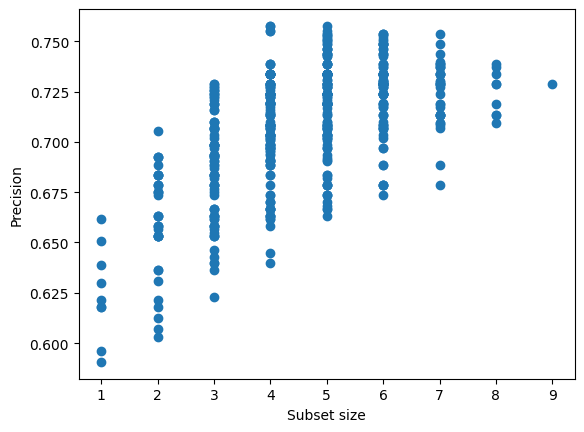

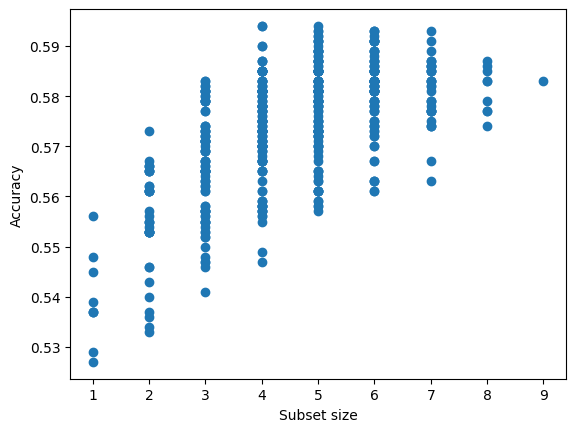

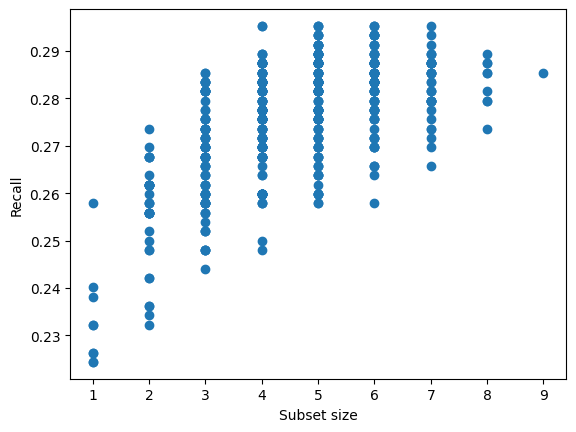

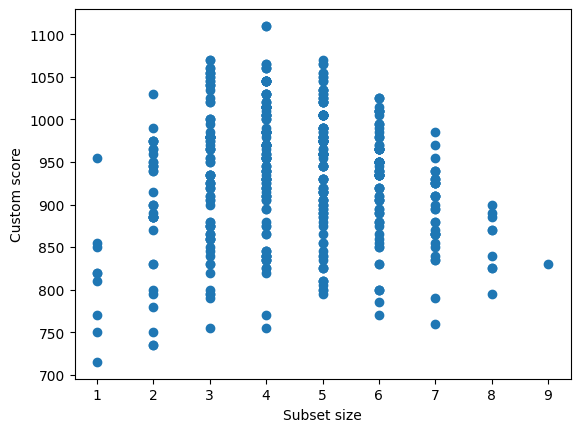

In [9]:
best_model,best_ft,df,all_subsets=train_model_all_combinations(x_t,y_t,x_tst,y_tst,max_subset=selected_second_level_subset,return_metrics=True)

In [17]:
# #reload if needed:
# df=pd.read_csv(FILE_SUBSETS_RESULTS_DF,index_col='Subset index')
# with open(FILE_ALL_SUBSETS_DICT, 'r') as file:
#     all_subsets = json.load(file)
# all_subsets = {int(k): v for k, v in all_subsets.items()}

In [10]:
df=df.sort_values(by="Precision", ascending=False)
df_top10_prec=df.head(10)

print(df_top10_prec)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
480                 1070.0   0.757576     0.594  0.295276
479                 1110.0   0.757576     0.594  0.295276
224                 1110.0   0.757576     0.594  0.295276
356                 1025.0   0.755208     0.590  0.285433
100                 1065.0   0.755208     0.590  0.285433
355                 1065.0   0.755208     0.590  0.285433
236                 1025.0   0.753769     0.593  0.295276
116                 1065.0   0.753769     0.593  0.295276
491                 1025.0   0.753769     0.593  0.295276
492                  985.0   0.753769     0.593  0.295276


In [8]:
df=df.sort_values(by="Custom Score", ascending=False)
df_top10_score=df.head(10)

print(df_top10_score)

              Custom Score  Precision  Accuracy    Recall
Subset index                                             
90                  1200.0   0.798995     0.611  0.312992
112                 1195.0   0.783920     0.605  0.307087
114                 1170.0   0.795918     0.608  0.307087
58                  1160.0   0.787879     0.606  0.307087
91                  1155.0   0.772727     0.600  0.301181
50                  1150.0   0.768844     0.599  0.301181
122                 1145.0   0.793970     0.609  0.311024
42                  1145.0   0.771574     0.599  0.299213
94                  1145.0   0.793970     0.609  0.311024
84                  1135.0   0.763819     0.597  0.299213


In [12]:
df.to_csv(FILE_SUBSETS_RESULTS_DF, index=True)
save_dict_to_json(all_subsets,FILE_ALL_SUBSETS_DICT)


Successfully saved data to C:\Users\andrz\-Cost-Sensitive-Predictive-Modeling\experiment_results\rf_common\all_subsets_dict.json


# for top 10 feature subsets conduct hyperparameter tuning, at one split.

In [13]:
#initialize a dict for the results of hyperparameter tuning for top 10 subsets
top10_hyperparameter_tuning_result_dict = {
    idx: {}
    for idx in df_top10_prec.index
}

In [14]:
for ind in df_top10_prec.index:
    print("=========================================")
    print(f"subset {ind}: {all_subsets[ind]}")
    print("=========================================")
    best_c_hyperparams,best_p_hyperparams=final_xgb_hyperparameter_grid_optimizer(x_t.loc[:,all_subsets[ind]],y_t,x_tst.loc[:,all_subsets[ind]],y_tst)
    xgb=XGBClassifier(max_depth=best_c_hyperparams['max_depth'],n_estimators=best_c_hyperparams['n_estimators'],learning_rate=best_c_hyperparams['lr'],random_state=7)
    xgb.fit(x_t.loc[:,all_subsets[ind]],y_t)
    y_pred_proba=xgb.predict_proba(x_tst.loc[:,all_subsets[ind]])[:,1]
    best_score,best_threshold, best_k, best_fp, best_tp=score_model_optimal_k(y_tst,y_pred_proba,len(all_subsets[ind]),keep_fp_tp=True,max_k=200,feature_penalty=40)
    top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']=best_c_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_p_hyperparams']=best_p_hyperparams
    top10_hyperparameter_tuning_result_dict[ind]['best_threshold']=best_threshold
    top10_hyperparameter_tuning_result_dict[ind]['best_score']=best_score
    top10_hyperparameter_tuning_result_dict[ind]['best_fp']=best_fp
    top10_hyperparameter_tuning_result_dict[ind]['best_tp']=best_tp
    top10_hyperparameter_tuning_result_dict[ind]['subset_list']=all_subsets[ind] # added for easier reloading
    print("=======================================")
    print(f"Score for subset {all_subsets[ind]}")
    print(f"best score: {best_score}, best threshold: {best_threshold}, fp:{best_fp}, tp:{best_tp}")
    print(f"best custom hyperparameters: {best_c_hyperparams}")
    print(f"best precision hyperparameters: {best_p_hyperparams}")
    print("=======================================")
save_dict_to_json(top10_hyperparameter_tuning_result_dict,FILE_BEST_AFTER_TUNING)

subset 480: ['V416', 'V191', 'V265', 'V224', 'V160']
Score for subset ['V416', 'V191', 'V265', 'V224', 'V160']
best score: 1125, best threshold: 0.6191174983978271, fp:45, tp:155
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.01}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.01}
subset 479: ['V191', 'V265', 'V224', 'V160']
Score for subset ['V191', 'V265', 'V224', 'V160']
best score: 1165, best threshold: 0.6191174983978271, fp:45, tp:155
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.01}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.01}
subset 224: ['V416', 'V191', 'V265', 'V224']
Score for subset ['V416', 'V191', 'V265', 'V224']
best score: 1165, best threshold: 0.6191174983978271, fp:45, tp:155
best custom hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.01}
best precision hyperparameters: {'max_depth': 1, 'n_estimators': 3000, 'lr': 0.01}
subset

In [15]:
#create a df with the scores of the top10 subsets for easier further selection and get 4 top subset indices
auxliary_data = [
    {'ind': key, 'score': value['best_score']}
    for key, value in top10_hyperparameter_tuning_result_dict.items()
]
auxiliary_df = pd.DataFrame(auxliary_data)
auxiliary_df=auxiliary_df.sort_values(by="score", ascending=False)
top10_subset_indices=auxiliary_df.head(10).loc[:,"ind"].tolist()
# a dictionary for results of multi-split check
top10_multisplit_result_dict = {
    idx: {}
    for idx in top10_subset_indices
}

In [24]:
print(auxiliary_df)

   ind  score
2   61   1260
4   62   1250
1  126   1210
5   54   1205
9   58   1200
0   46   1195
3  110   1175
7  125   1175
8   94   1175
6   29   1165


In [17]:
for ind in top10_subset_indices:
    scores,precs=check_xgb_model_with_multi_split(x.loc[:, top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y,max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'], n_estimators=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['n_estimators'], learning_rate=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['lr'],n_checks=50,threshold=top10_hyperparameter_tuning_result_dict[ind]['best_threshold'])
    top10_multisplit_result_dict[ind]['scores']=scores
    top10_multisplit_result_dict[ind]['precs']=precs
    print(f"check done for index: {ind}")
save_dict_to_json(top10_multisplit_result_dict,FILE_MULTI_RUN_TOP10_SUBSETS_RESULTS)

no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives in splitted sample: 498
no. of positives

C:\Users\andrz\AppData\Local\Temp\ipykernel_5984\2730525874.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


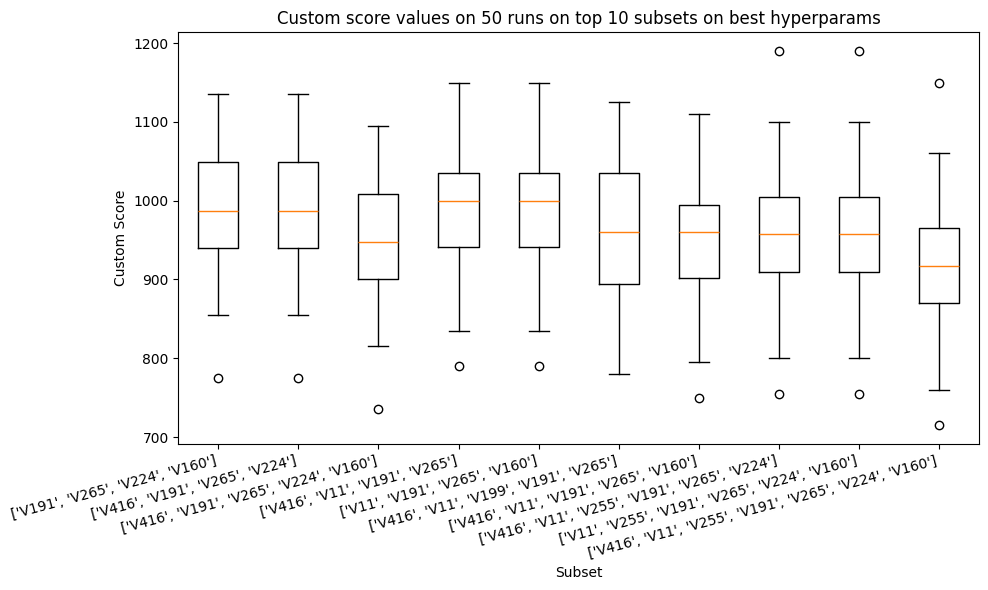

In [18]:
#plotting - custom scores (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['scores'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Custom Score")
plt.title("Custom score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "custom_score_50runs_boxplot.png"))
plt.show()

C:\Users\andrz\AppData\Local\Temp\ipykernel_5984\3926348023.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


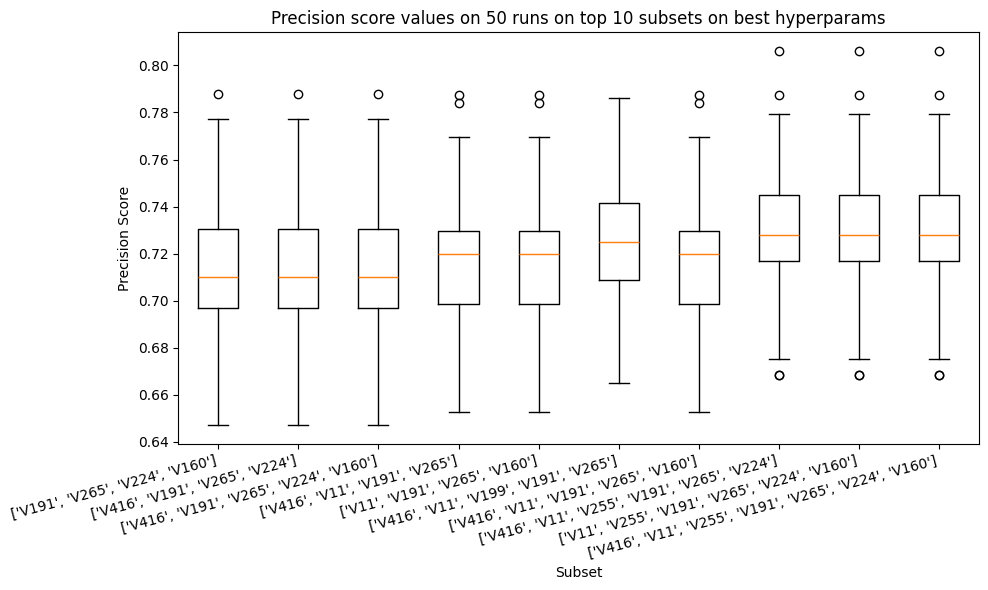

In [19]:
#plotting - precisions (may be optional, but probably at this level the best will be selected manually)
data_to_plot = []
labels = []

for ind in top10_subset_indices:
    data_to_plot.append(top10_multisplit_result_dict[ind]['precs'])
    labels.append(str(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot, labels=labels)

plt.xlabel("Subset")
plt.ylabel("Precision Score")
plt.title("Precision score values on 50 runs on top 10 subsets on best hyperparams")
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(Path(PLOT_DIR / "precision_50runs_boxplot.png"))
plt.show()

In [20]:
top10_cv_result_dict={
    ind:{}
    for ind in top10_subset_indices
}
for ind in top10_subset_indices:
    print(f"checking cv score for subset: {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    all_y_pred=(all_y_prob>score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']))[1]).astype(int)
    print(precision_score(all_y_test,all_y_pred))
    top10_cv_result_dict[ind]["precision"]=precision_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["accuracy"]=accuracy_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["recall"]=recall_score(all_y_test,all_y_pred)
    top10_cv_result_dict[ind]["cv_custom_score"],top10_cv_result_dict[ind]["cv_best_threshold"]=score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True)[:2]
    print(score_model_optimal_k(all_y_test,all_y_prob,n_vars=len(top10_hyperparameter_tuning_result_dict[ind]['subset_list']),keep_fp_tp=True))
    print("===============================================")
# save_dict_to_json(top10_cv_result_dict,FILE_CV_TOP10_SUBSETS_RESULTS)

checking cv score for subset: ['V191', 'V265', 'V224', 'V160']
0.720440881763527
(5015, np.float32(0.6216711), 1000, 279, 721)
checking cv score for subset: ['V416', 'V191', 'V265', 'V224']
0.720440881763527
(5015, np.float32(0.6216711), 1000, 279, 721)
checking cv score for subset: ['V416', 'V191', 'V265', 'V224', 'V160']
0.720440881763527
(4815, np.float32(0.6216711), 1000, 279, 721)
checking cv score for subset: ['V416', 'V11', 'V191', 'V265']
0.7137137137137137
(4910, np.float32(0.6210469), 1000, 286, 714)
checking cv score for subset: ['V11', 'V191', 'V265', 'V160']
0.7137137137137137
(4910, np.float32(0.6210469), 1000, 286, 714)
checking cv score for subset: ['V416', 'V11', 'V199', 'V191', 'V265']
0.7214428857715431
(4820, np.float32(0.62839156), 999, 278, 721)
checking cv score for subset: ['V416', 'V11', 'V191', 'V265', 'V160']
0.7137137137137137
(4710, np.float32(0.6210469), 1000, 286, 714)
checking cv score for subset: ['V416', 'V11', 'V255', 'V191', 'V265', 'V224']
0.7317317

# before decision run calibration check

checking calibration for subset ['V191', 'V265', 'V224', 'V160']
Bin  1 | n= 500 | mean_pred=0.323 | frac_pos=0.336
Bin  2 | n= 499 | mean_pred=0.362 | frac_pos=0.363
Bin  3 | n= 501 | mean_pred=0.389 | frac_pos=0.401
Bin  4 | n= 500 | mean_pred=0.416 | frac_pos=0.374
Bin  5 | n= 500 | mean_pred=0.447 | frac_pos=0.422
Bin  6 | n= 500 | mean_pred=0.485 | frac_pos=0.508
Bin  7 | n= 500 | mean_pred=0.532 | frac_pos=0.536
Bin  8 | n= 500 | mean_pred=0.588 | frac_pos=0.594
Bin  9 | n= 500 | mean_pred=0.659 | frac_pos=0.692
Bin 10 | n= 500 | mean_pred=0.777 | frac_pos=0.750


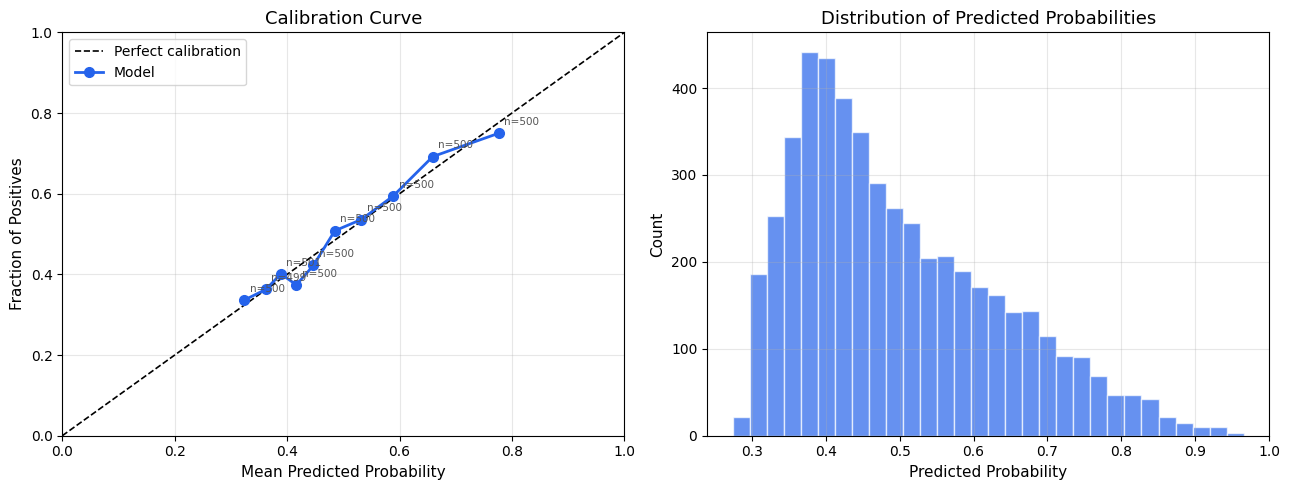

checking calibration for subset ['V416', 'V191', 'V265', 'V224']
Bin  1 | n= 500 | mean_pred=0.323 | frac_pos=0.336
Bin  2 | n= 499 | mean_pred=0.362 | frac_pos=0.363
Bin  3 | n= 501 | mean_pred=0.389 | frac_pos=0.401
Bin  4 | n= 500 | mean_pred=0.416 | frac_pos=0.374
Bin  5 | n= 500 | mean_pred=0.447 | frac_pos=0.422
Bin  6 | n= 500 | mean_pred=0.485 | frac_pos=0.508
Bin  7 | n= 500 | mean_pred=0.532 | frac_pos=0.536
Bin  8 | n= 500 | mean_pred=0.588 | frac_pos=0.594
Bin  9 | n= 500 | mean_pred=0.659 | frac_pos=0.692
Bin 10 | n= 500 | mean_pred=0.777 | frac_pos=0.750


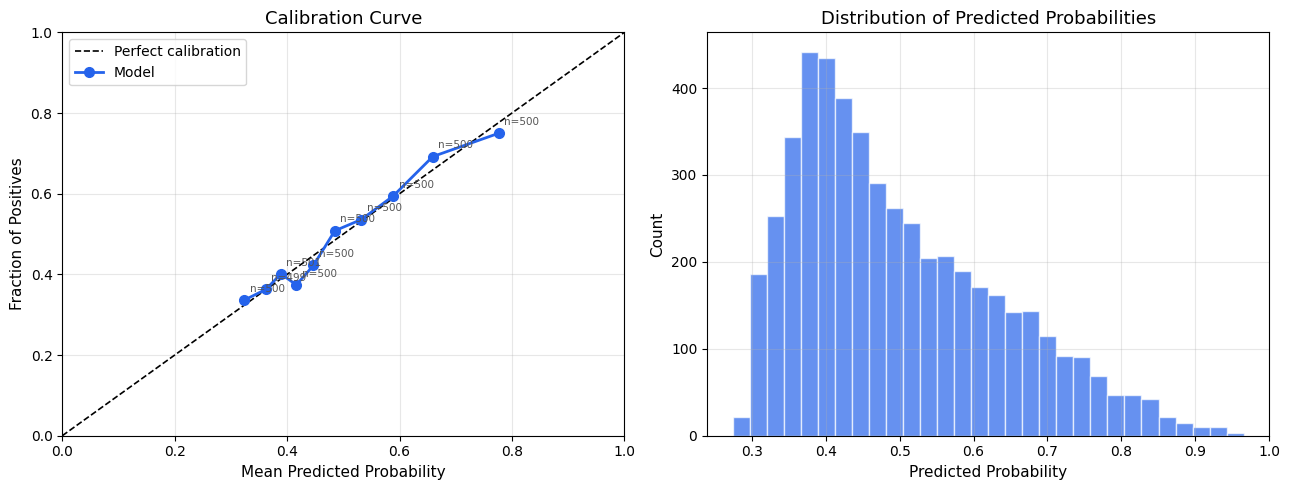

checking calibration for subset ['V416', 'V191', 'V265', 'V224', 'V160']
Bin  1 | n= 500 | mean_pred=0.323 | frac_pos=0.336
Bin  2 | n= 499 | mean_pred=0.362 | frac_pos=0.363
Bin  3 | n= 501 | mean_pred=0.389 | frac_pos=0.401
Bin  4 | n= 500 | mean_pred=0.416 | frac_pos=0.374
Bin  5 | n= 500 | mean_pred=0.447 | frac_pos=0.422
Bin  6 | n= 500 | mean_pred=0.485 | frac_pos=0.508
Bin  7 | n= 500 | mean_pred=0.532 | frac_pos=0.536
Bin  8 | n= 500 | mean_pred=0.588 | frac_pos=0.594
Bin  9 | n= 500 | mean_pred=0.659 | frac_pos=0.692
Bin 10 | n= 500 | mean_pred=0.777 | frac_pos=0.750


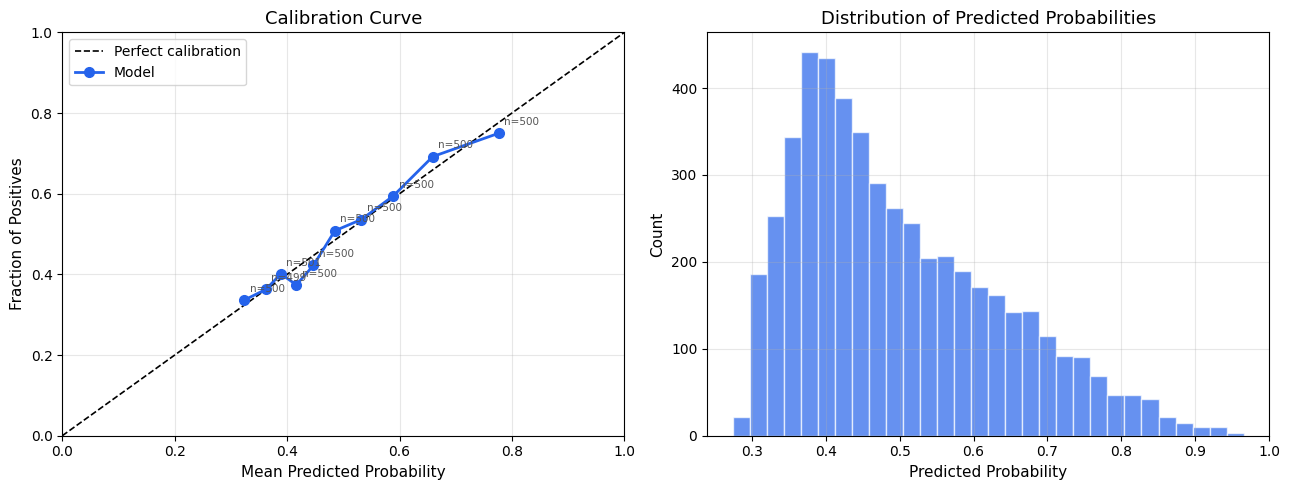

checking calibration for subset ['V416', 'V11', 'V191', 'V265']
Bin  1 | n= 499 | mean_pred=0.322 | frac_pos=0.337
Bin  2 | n= 501 | mean_pred=0.361 | frac_pos=0.329
Bin  3 | n= 500 | mean_pred=0.388 | frac_pos=0.384
Bin  4 | n= 500 | mean_pred=0.417 | frac_pos=0.428
Bin  5 | n= 500 | mean_pred=0.449 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.486 | frac_pos=0.488
Bin  7 | n= 500 | mean_pred=0.533 | frac_pos=0.512
Bin  8 | n= 499 | mean_pred=0.589 | frac_pos=0.627
Bin  9 | n= 501 | mean_pred=0.657 | frac_pos=0.681
Bin 10 | n= 500 | mean_pred=0.774 | frac_pos=0.746


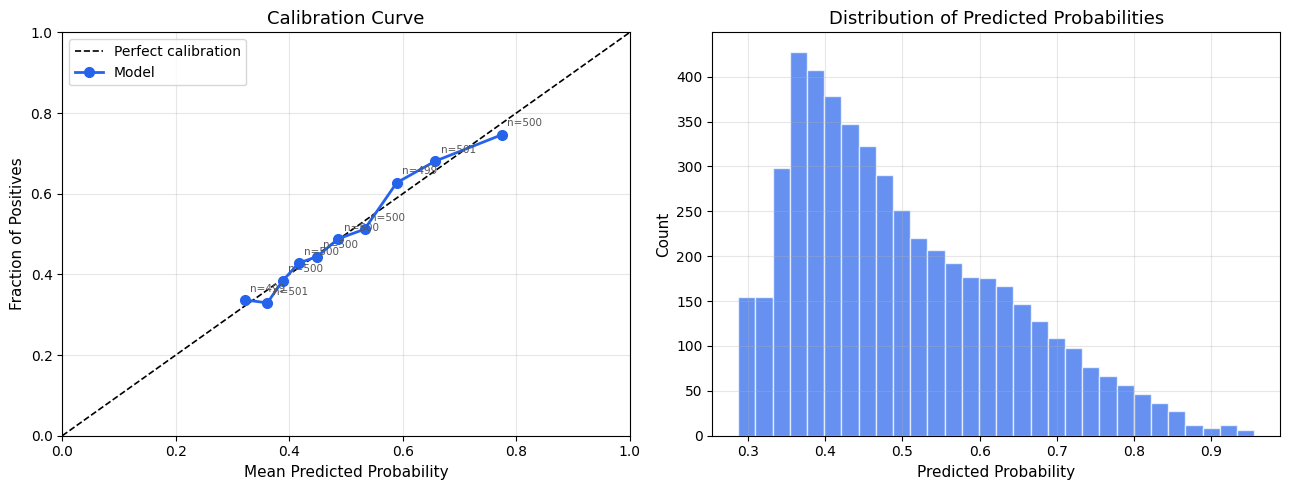

checking calibration for subset ['V11', 'V191', 'V265', 'V160']
Bin  1 | n= 499 | mean_pred=0.322 | frac_pos=0.337
Bin  2 | n= 501 | mean_pred=0.361 | frac_pos=0.329
Bin  3 | n= 500 | mean_pred=0.388 | frac_pos=0.384
Bin  4 | n= 500 | mean_pred=0.417 | frac_pos=0.428
Bin  5 | n= 500 | mean_pred=0.449 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.486 | frac_pos=0.488
Bin  7 | n= 500 | mean_pred=0.533 | frac_pos=0.512
Bin  8 | n= 499 | mean_pred=0.589 | frac_pos=0.627
Bin  9 | n= 501 | mean_pred=0.657 | frac_pos=0.681
Bin 10 | n= 500 | mean_pred=0.774 | frac_pos=0.746


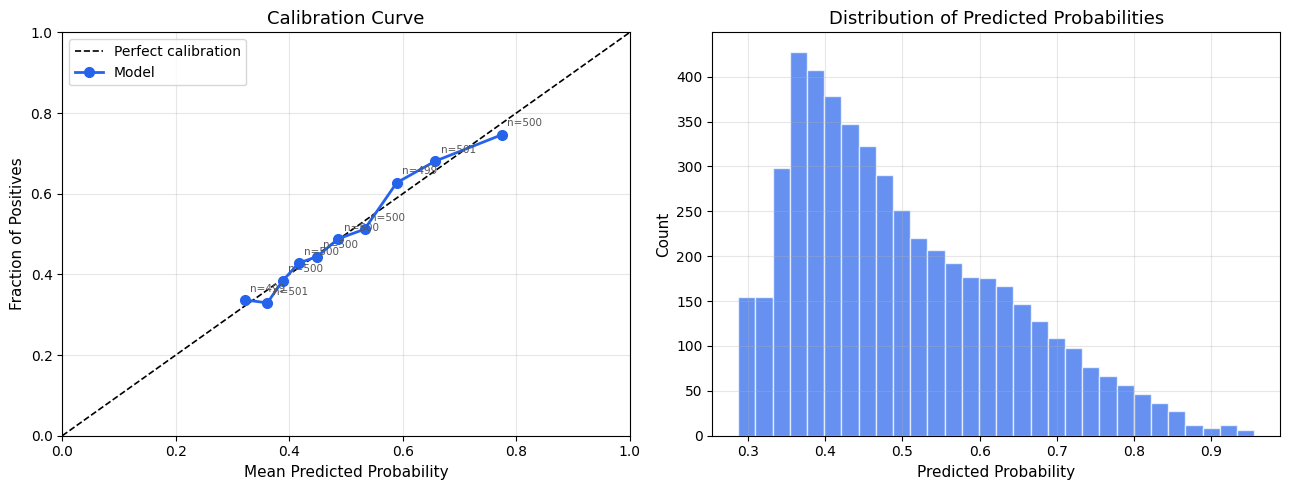

checking calibration for subset ['V416', 'V11', 'V199', 'V191', 'V265']
Bin  1 | n= 500 | mean_pred=0.311 | frac_pos=0.316
Bin  2 | n= 500 | mean_pred=0.351 | frac_pos=0.324
Bin  3 | n= 500 | mean_pred=0.382 | frac_pos=0.384
Bin  4 | n= 500 | mean_pred=0.414 | frac_pos=0.412
Bin  5 | n= 500 | mean_pred=0.449 | frac_pos=0.442
Bin  6 | n= 500 | mean_pred=0.492 | frac_pos=0.484
Bin  7 | n= 500 | mean_pred=0.540 | frac_pos=0.538
Bin  8 | n= 500 | mean_pred=0.596 | frac_pos=0.634
Bin  9 | n= 500 | mean_pred=0.664 | frac_pos=0.684
Bin 10 | n= 500 | mean_pred=0.783 | frac_pos=0.758


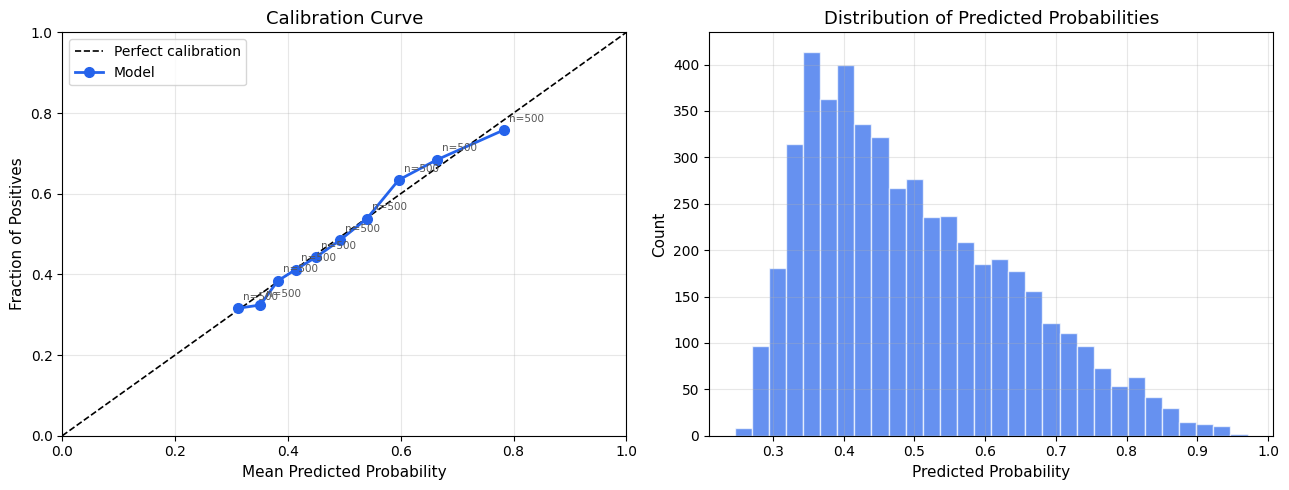

checking calibration for subset ['V416', 'V11', 'V191', 'V265', 'V160']
Bin  1 | n= 499 | mean_pred=0.322 | frac_pos=0.337
Bin  2 | n= 501 | mean_pred=0.361 | frac_pos=0.329
Bin  3 | n= 500 | mean_pred=0.388 | frac_pos=0.384
Bin  4 | n= 500 | mean_pred=0.417 | frac_pos=0.428
Bin  5 | n= 500 | mean_pred=0.449 | frac_pos=0.444
Bin  6 | n= 500 | mean_pred=0.486 | frac_pos=0.488
Bin  7 | n= 500 | mean_pred=0.533 | frac_pos=0.512
Bin  8 | n= 499 | mean_pred=0.589 | frac_pos=0.627
Bin  9 | n= 501 | mean_pred=0.657 | frac_pos=0.681
Bin 10 | n= 500 | mean_pred=0.774 | frac_pos=0.746


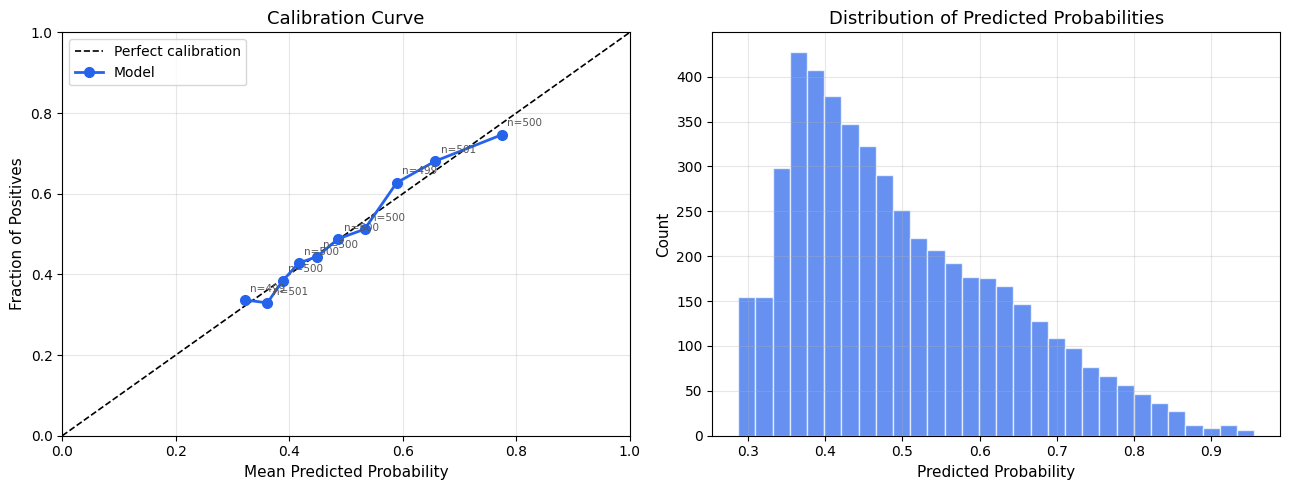

checking calibration for subset ['V416', 'V11', 'V255', 'V191', 'V265', 'V224']
Bin  1 | n= 494 | mean_pred=0.303 | frac_pos=0.291
Bin  2 | n= 506 | mean_pred=0.343 | frac_pos=0.322
Bin  3 | n= 500 | mean_pred=0.374 | frac_pos=0.378
Bin  4 | n= 500 | mean_pred=0.409 | frac_pos=0.398
Bin  5 | n= 500 | mean_pred=0.448 | frac_pos=0.428
Bin  6 | n= 500 | mean_pred=0.494 | frac_pos=0.494
Bin  7 | n= 500 | mean_pred=0.544 | frac_pos=0.552
Bin  8 | n= 500 | mean_pred=0.598 | frac_pos=0.648
Bin  9 | n= 500 | mean_pred=0.668 | frac_pos=0.688
Bin 10 | n= 500 | mean_pred=0.796 | frac_pos=0.776


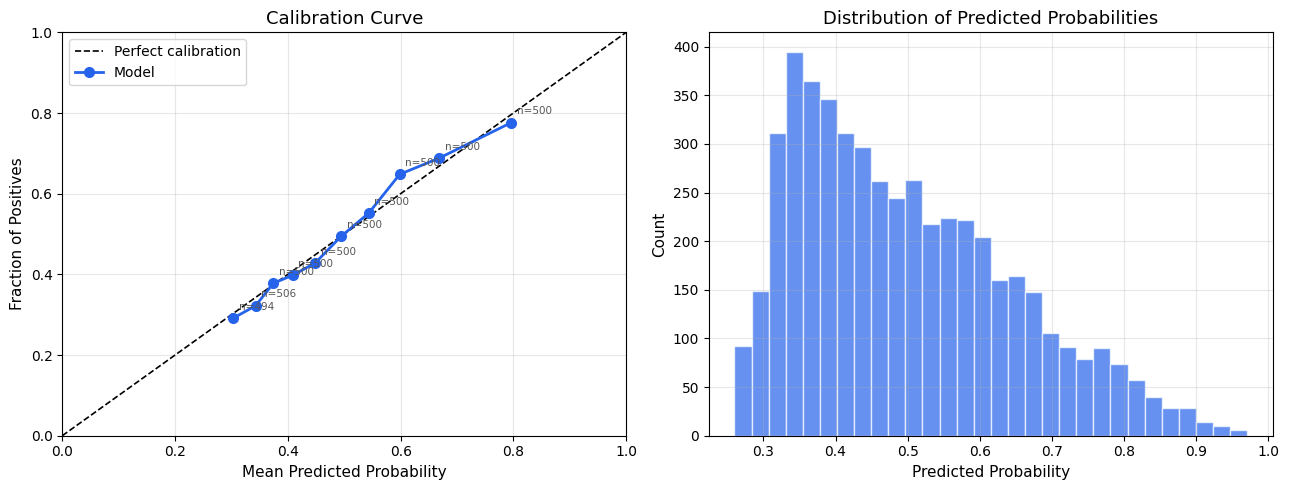

checking calibration for subset ['V11', 'V255', 'V191', 'V265', 'V224', 'V160']
Bin  1 | n= 494 | mean_pred=0.303 | frac_pos=0.291
Bin  2 | n= 506 | mean_pred=0.343 | frac_pos=0.322
Bin  3 | n= 500 | mean_pred=0.374 | frac_pos=0.378
Bin  4 | n= 500 | mean_pred=0.409 | frac_pos=0.398
Bin  5 | n= 500 | mean_pred=0.448 | frac_pos=0.428
Bin  6 | n= 500 | mean_pred=0.494 | frac_pos=0.494
Bin  7 | n= 500 | mean_pred=0.544 | frac_pos=0.552
Bin  8 | n= 500 | mean_pred=0.598 | frac_pos=0.648
Bin  9 | n= 500 | mean_pred=0.668 | frac_pos=0.688
Bin 10 | n= 500 | mean_pred=0.796 | frac_pos=0.776


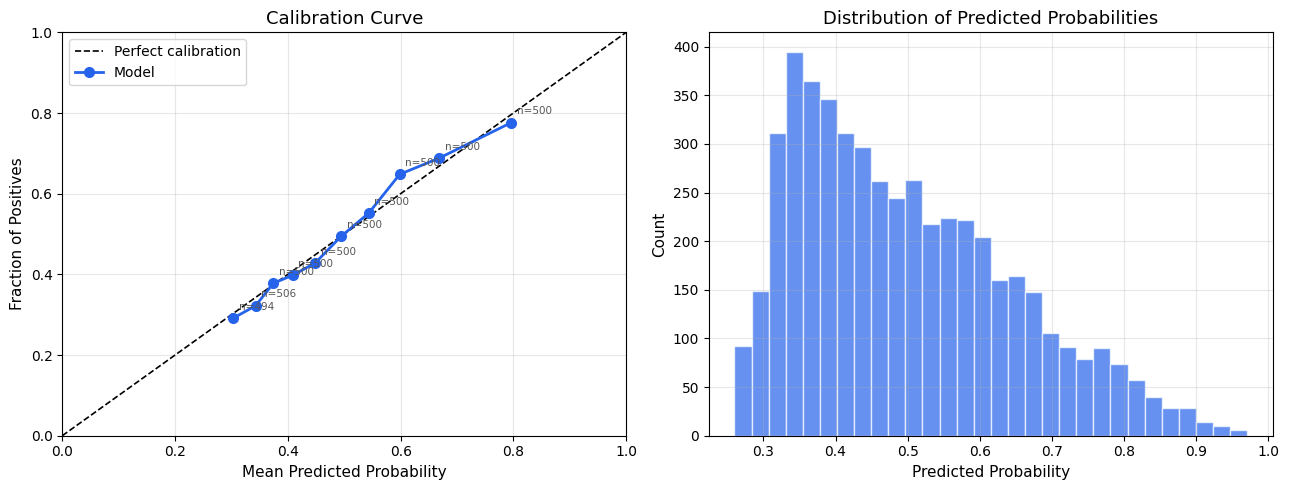

checking calibration for subset ['V416', 'V11', 'V255', 'V191', 'V265', 'V224', 'V160']
Bin  1 | n= 494 | mean_pred=0.303 | frac_pos=0.291
Bin  2 | n= 506 | mean_pred=0.343 | frac_pos=0.322
Bin  3 | n= 500 | mean_pred=0.374 | frac_pos=0.378
Bin  4 | n= 500 | mean_pred=0.409 | frac_pos=0.398
Bin  5 | n= 500 | mean_pred=0.448 | frac_pos=0.428
Bin  6 | n= 500 | mean_pred=0.494 | frac_pos=0.494
Bin  7 | n= 500 | mean_pred=0.544 | frac_pos=0.552
Bin  8 | n= 500 | mean_pred=0.598 | frac_pos=0.648
Bin  9 | n= 500 | mean_pred=0.668 | frac_pos=0.688
Bin 10 | n= 500 | mean_pred=0.796 | frac_pos=0.776


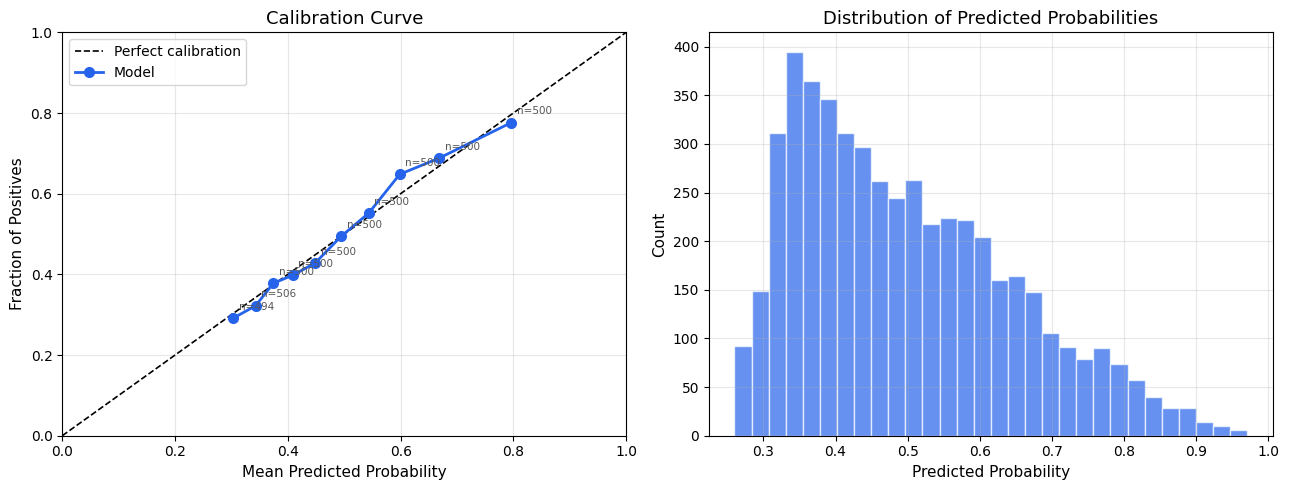

In [21]:
for ind in top10_subset_indices:
    print(f"checking calibration for subset {top10_hyperparameter_tuning_result_dict[ind]['subset_list']}")
    model=XGBClassifier(max_depth=top10_hyperparameter_tuning_result_dict[ind]['best_c_hyperparams']['max_depth'])
    all_y_test,all_y_prob=get_cv_calibration_predictions(model,x.loc[:,top10_hyperparameter_tuning_result_dict[ind]['subset_list']],y)
    check_calibration(all_y_prob,all_y_test,savename=Path(PLOT_DIR / f"calibration_for_subset_{ind}"))
    print("===============================================")